In [75]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

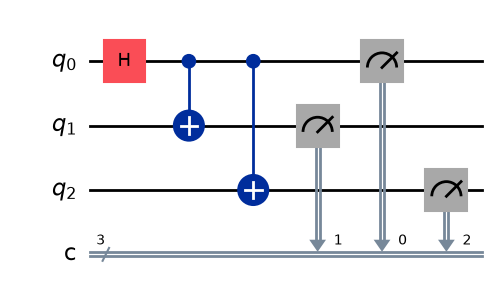

In [76]:
circuit = QuantumCircuit(3, 3)
circuit.h(0)
circuit.cx(0, 1)
circuit.cx(0, 2)

circuit.measure([0, 1, 2], [0, 1, 2])

circuit.draw(output="mpl")

C:\Users\felix\AppData\Local\Temp\ipykernel_22552\639705136.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft=QFT(num_qubits=4, do_swaps=True)


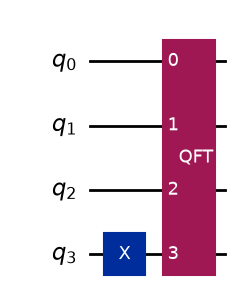

In [77]:
circuit_QFT = QuantumCircuit(4)

circuit_QFT.x(3)

qft = QFT(num_qubits=4, do_swaps=True)
circuit_QFT.compose(qft, inplace=True)

circuit_QFT.draw(output="mpl")

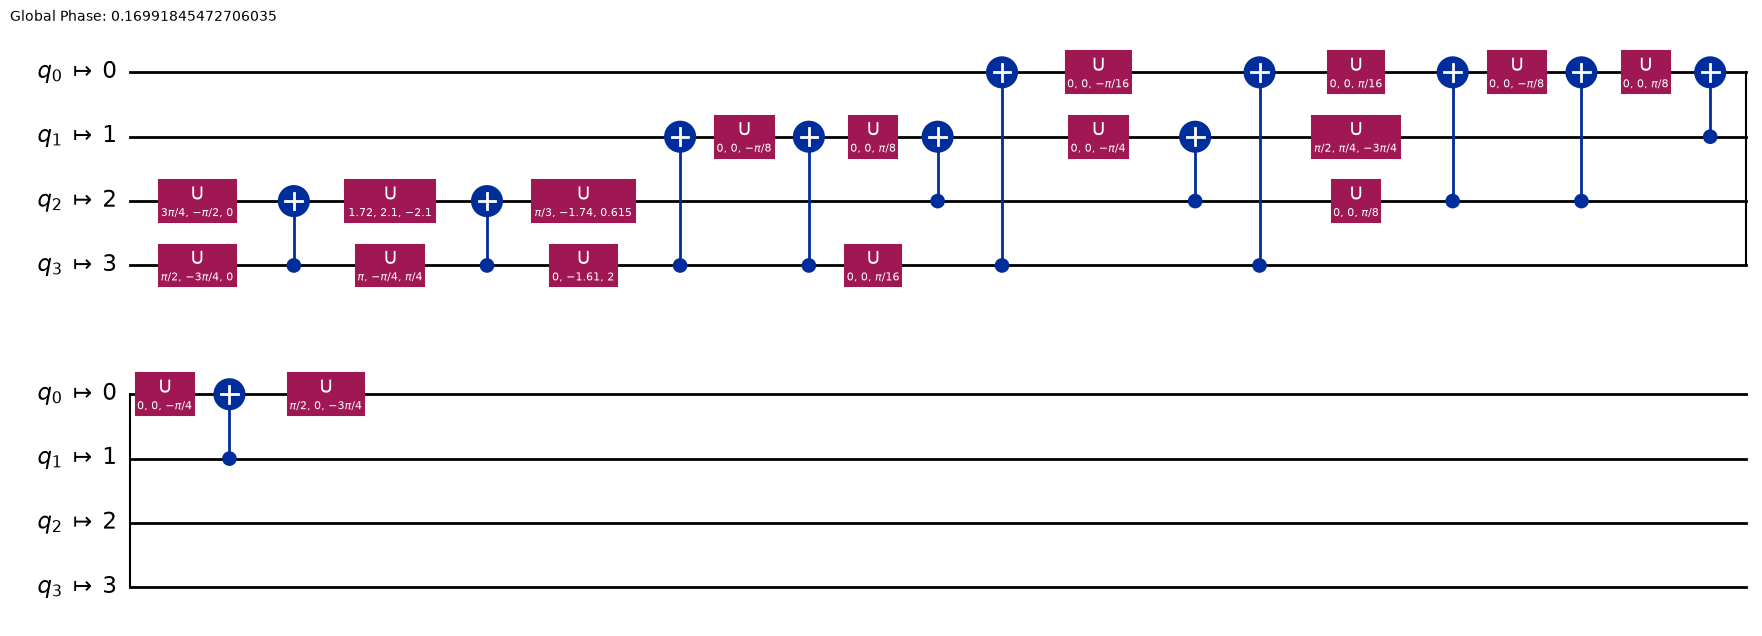

In [78]:
transpiled_circuit = transpile(
    circuit_QFT, basis_gates=["u", "cx"], optimization_level=3
)
transpiled_circuit.draw(output="mpl")

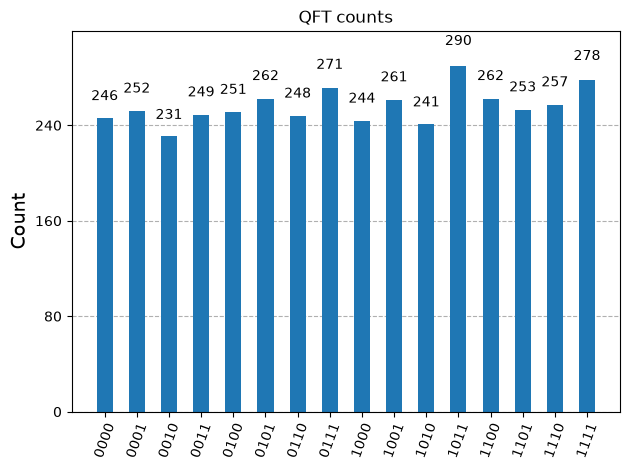

In [79]:
measured_QFT = transpiled_circuit.copy()

measured_QFT.measure_all()

simulator = AerSimulator()
circ = transpile(measured_QFT, simulator)


result = simulator.run(circ, shots=4096).result()
counts = result.get_counts(circ)
plot_histogram(counts, title="QFT counts")

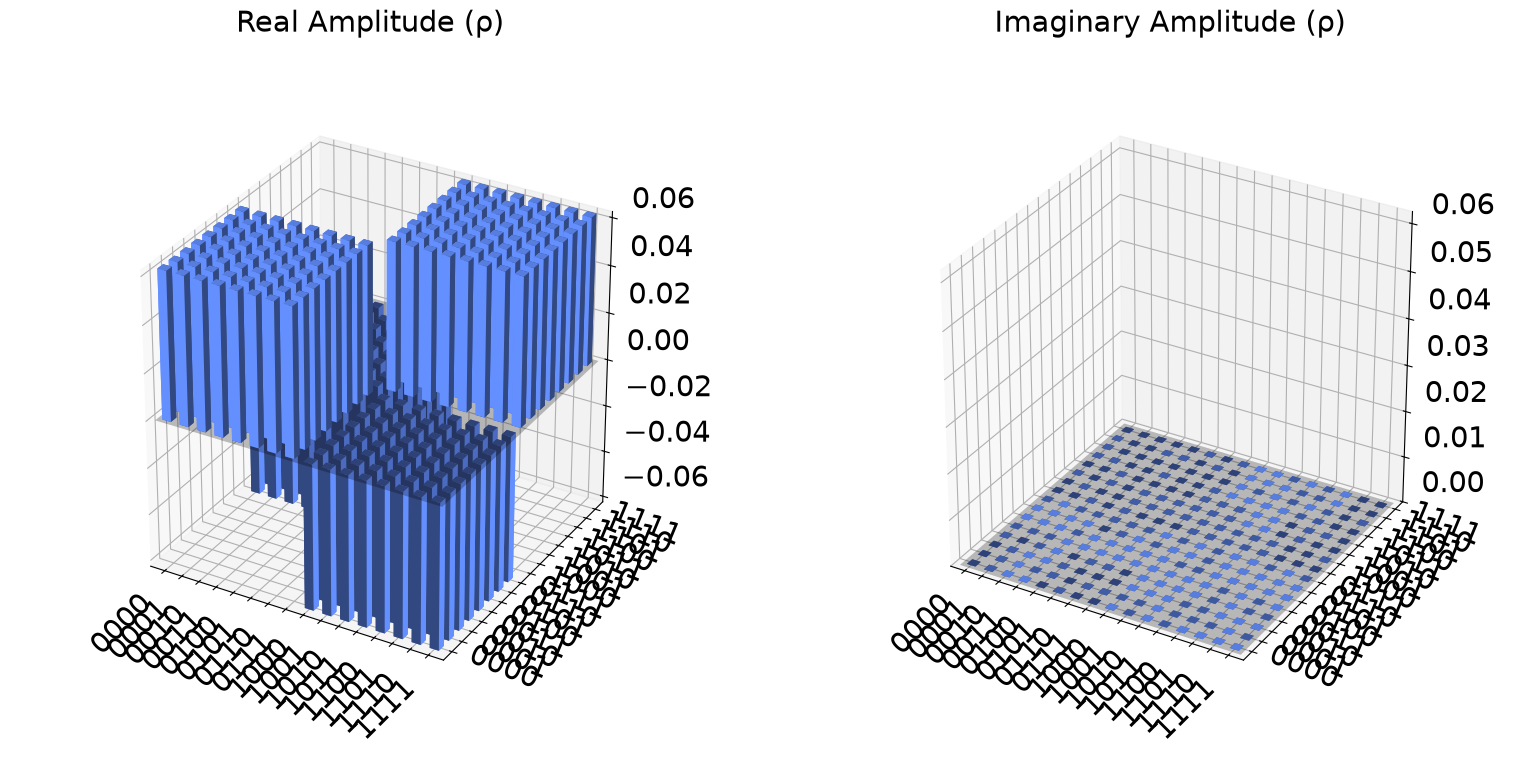

In [80]:
sv = Statevector(transpiled_circuit)
sv.draw(output="city")

C:\Users\felix\AppData\Local\Temp\ipykernel_22552\3245921696.py:5: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft2=QFT(num_qubits=4, do_swaps=True)


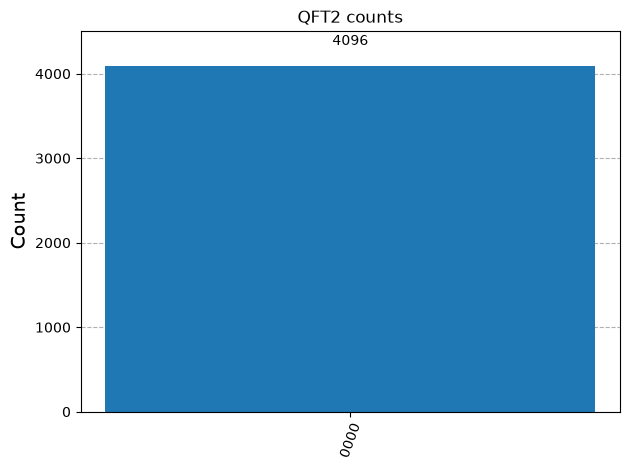

In [81]:
circuit_QFT2 = QuantumCircuit(4)

circuit_QFT2.h([0, 1, 2, 3])

qft2 = QFT(num_qubits=4, do_swaps=True)
circuit_QFT2.compose(qft2, inplace=True)

transpiled_circuit2 = transpile(
    circuit_QFT2, basis_gates=["u", "cx"], optimization_level=3
)

measured_QFT2 = transpiled_circuit2.copy()

measured_QFT2.measure_all()

simulator = AerSimulator()
circ2 = transpile(measured_QFT2, simulator)


result2 = simulator.run(circ2, shots=4096).result()
counts2 = result2.get_counts(circ2)
plot_histogram(counts2, title="QFT2 counts")